# Shoplifting & Suspicious Movement Detection (Step-by-Step)

This notebook demonstrates an end-to-end computer vision pipeline for **Shoplifting and Suspicious Action Detection** using **YOLO-Pose** body keypoint estimation and spatial-temporal motion heuristics.

### Pipeline Overview:
1. **Video Ingestion & Metadata Inspection**: Load the sample video and inspect properties (Resolution, FPS, Duration).
2. **YOLO-Pose Keypoint Extraction**: Detect 17 COCO body keypoints (wrists, elbows, shoulders, hips) for each person in real time.
3. **Spatial-Temporal Motion Analysis**: Calculate hand-to-pocket/waistband proximity, wrist motion velocity, and suspicious posture scores.
4. **Frame Annotation & Visual Overlay**: Render color-coded skeleton joints, bounding boxes, suspicion progress gauges, and alert banners.
5. **Output Video Export**: Write the fully annotated video to disk (`sample_videos/output_shoplifting_detection.mp4`).

--- 
## Step 1: Import Dependencies & System Setup

In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML
from ultralytics import YOLO

# Check device acceleration (MPS for Mac Apple Silicon / CUDA for Nvidia / CPU fallback)
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"PyTorch Version: {torch.__version__}")
print(f"OpenCV Version: {cv2.__version__}")
print(f"Using Hardware Accelerator: {device.upper()}")

PyTorch Version: 2.13.0
OpenCV Version: 5.0.0
Using Hardware Accelerator: MPS


--- 
## Step 2: Load Sample Video & Inspect Metadata

=== Input Video Metadata ===
File Path    : sample_videos/gettyimages-1995820194-640_adpp.mp4
Resolution   : 768 x 432
Frame Rate   : 29.97 FPS
Total Frames : 658
Duration     : 21.96 seconds


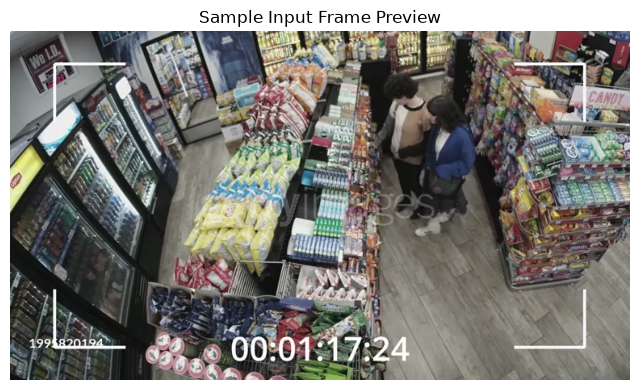

In [2]:
video_path = os.path.join("sample_videos", "gettyimages-1995820194-640_adpp.mp4")

if not os.path.exists(video_path):
    raise FileNotFoundError(f"Video file not found at: {video_path}")

cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = float(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_sec = total_frames / fps if fps > 0 else 0

print("=== Input Video Metadata ===")
print(f"File Path    : {video_path}")
print(f"Resolution   : {width} x {height}")
print(f"Frame Rate   : {fps:.2f} FPS")
print(f"Total Frames : {total_frames}")
print(f"Duration     : {duration_sec:.2f} seconds")

# Preview first frame
ret, sample_frame = cap.read()
cap.release()

if ret:
    sample_frame_rgb = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 5))
    plt.imshow(sample_frame_rgb)
    plt.title("Sample Input Frame Preview")
    plt.axis("off")
    plt.show()
else:
    print("Could not read sample frame.")

--- 
## Step 3: Load YOLO-Pose Model

In [3]:
# Load lightweight YOLOv8-pose model
model = YOLO('yolov8n-pose.pt')

# COCO Keypoints Mapping (17 joints)
COCO_KEYPOINTS = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle"
]

print("YOLOv8-Pose model loaded successfully!")
print("COCO Keypoint Indices:")
for idx, name in enumerate(COCO_KEYPOINTS):
    print(f"  {idx:2d}: {name}")

YOLOv8-Pose model loaded successfully!
COCO Keypoint Indices:
   0: nose
   1: left_eye
   2: right_eye
   3: left_ear
   4: right_ear
   5: left_shoulder
   6: right_shoulder
   7: left_elbow
   8: right_elbow
   9: left_wrist
  10: right_wrist
  11: left_hip
  12: right_hip
  13: left_knee
  14: right_knee
  15: left_ankle
  16: right_ankle


--- 
## Step 4: Define Spatial-Temporal Suspicious Motion Heuristics

In [4]:
# Keypoint indices
L_SHOULDER, R_SHOULDER = 5, 6
L_ELBOW, R_ELBOW       = 7, 8
L_WRIST, R_WRIST       = 9, 10
L_HIP, R_HIP           = 11, 12

# Scoring constants
MIN_CONF = 0.3            # keypoint confidence threshold
DEEP_DEPTH = 0.20         # torso units below hip line = "bag depth"
DEEP_STREAK_MIN = 14      # consecutive bag-depth frames to count a hand
IN_BAG_EXIT_FRAMES = 6    # frames above hip before "in bag" is dropped
BOTH_HANDS_MIN = 1        # both-below-hip frames = two-handed handling

# Chest-level concealment (bag held in front of the body)
CHEST_HIDE_CONF = 0.42    # hidden hand: wrist confidence drops below this
CHEST_ABSENT_CONF = 0.30  # ...and wrist+elbow fully absent below this
CHEST_HIDE_MIN = 6        # min streak frames of the hidden-hand pattern
CHEST_ABSENT_MIN = 2      # min fully-absent frames inside the streak
CHEST_OTHER_MIN = 0.70    # the visible hand must be confidently tracked
CHEST_D_LO, CHEST_D_HI = -0.30, 1.05  # visible hand held in front
CHEST_HOLD_D_LO, CHEST_HOLD_D_HI = 0.35, 1.05  # both hands at chest height
CHEST_HOLD_SPAN = 75.0    # px: hands close together (gripping one bag)
CHEST_HOLD_MIN = 12       # frames of two-hand chest hold to qualify
CHEST_EPISODE_GAP = 30    # link hidden-hand to a chest-hold within 30 frames

def analyze_person_pose(keypoints, confidences, pose_state=None):
    """
    Suspicion score (0.0-1.0) for one person, based on hand position
    relative to the hip line.

    Two independent evidence channels, both measured in torso units:

    1. "Hand in bag": a wrist that stays at bag depth (d <= -0.20 below
       the hip line) for DEEP_STREAK_MIN consecutive frames. In this
       video the thief's hand rests in her handbag for 29+ frames while
       every innocent behavior - picking products, walking arm swings,
       even a basket carried at side depth for 13 frames at the exit -
       stays under that threshold. Once in-bag, the hand stays counted
       until it returns clearly above hip level for 6 consecutive frames.

    2. Two-handed evidence: >= 2 consecutive frames with BOTH wrists
       below the hip line (d <= -0.05) - the thief joining her second
       hand into the bag to handle the concealed item. The innocent
       basket-carrier never produces this (max 1 frame).

    3. Chest-level concealment: the bag is held in front of the body, so
       the hand never dips below the hip. One hand disappears (wrist
       low-confidence, wrist+elbow fully absent on >= CHEST_ABSENT_MIN
       frames) while the other stays confidently visible in front, then
       both hands grip the bag at chest height for CHEST_HOLD_MIN frames
       within CHEST_EPISODE_GAP frames of the hidden window.

    The earlier transition scorer rewarded brief "hand near hip" events,
    which flagged an innocent standing person at 0.8 sustained and never
    registered the thief's bag work; the deep-streak gate and
    two-handed boost separate them cleanly.

    pose_state: per-track dict with previous wrist positions and the
    streak / in-bag / two-handed counters (None on the first frame).

    Returns (score, reasons, updated_pose_state).
    """
    score = 0.0
    reasons = []

    if pose_state is None:
        pose_state = {
            "prev_l_wrist": None, "prev_r_wrist": None,
            "l_streak": 0, "r_streak": 0,
            "l_in_bag": False, "r_in_bag": False,
            "l_exit": 0, "r_exit": 0,
            "both_count": 0,
            "chest_hide_streak": 0, "chest_absent": 0,
            "chest_hold_streak": 0,
            "chest_episode_active": False, "chest_episode_age": 0,
        }

    has_l_wrist = confidences[L_WRIST] > MIN_CONF
    has_r_wrist = confidences[R_WRIST] > MIN_CONF
    has_l_hip = confidences[L_HIP] > MIN_CONF
    has_r_hip = confidences[R_HIP] > MIN_CONF

    # Torso height as a scale reference for distances
    if confidences[L_SHOULDER] > MIN_CONF and confidences[L_HIP] > MIN_CONF:
        torso_height = np.linalg.norm(keypoints[L_SHOULDER] - keypoints[L_HIP])
    elif confidences[R_SHOULDER] > MIN_CONF and confidences[R_HIP] > MIN_CONF:
        torso_height = np.linalg.norm(keypoints[R_SHOULDER] - keypoints[R_HIP])
    else:
        torso_height = 100.0  # fallback
    torso_height = max(torso_height, 20.0)

    # Hip center (the reference line: below it = bag depth)
    hip_center = None
    if has_l_hip and has_r_hip:
        hip_center = (keypoints[L_HIP] + keypoints[R_HIP]) / 2.0
    elif has_l_hip:
        hip_center = keypoints[L_HIP]
    elif has_r_hip:
        hip_center = keypoints[R_HIP]

    if hip_center is not None:
        wrist_d = {}
        for side, widx, s_key, in_key, x_key in (
            ("Left", L_WRIST, "l_streak", "l_in_bag", "l_exit"),
            ("Right", R_WRIST, "r_streak", "r_in_bag", "r_exit"),
        ):
            if confidences[widx] <= MIN_CONF:
                continue  # keypoint lost: keep state, do not advance exits
            d = (hip_center[1] - keypoints[widx][1]) / torso_height
            wrist_d[side] = d

            if d <= -DEEP_DEPTH:
                # still at bag depth: build the streak, hold in-bag state
                pose_state[s_key] += 1
                pose_state[x_key] = 0
                if pose_state[s_key] >= DEEP_STREAK_MIN:
                    pose_state[in_key] = True
            elif d <= -0.05:
                # shallow dip below hip: breaks the streak, keeps in-bag
                pose_state[s_key] = 0
            else:
                # back above hip: start the exit counter
                pose_state[s_key] = 0
                pose_state[x_key] += 1
                if pose_state[x_key] >= IN_BAG_EXIT_FRAMES:
                    pose_state[in_key] = False
                    pose_state[x_key] = 0

        # 1. Hand-in-bag evidence
        for side, widx, in_key, prev_key in (
            ("Left", L_WRIST, "l_in_bag", "prev_l_wrist"),
            ("Right", R_WRIST, "r_in_bag", "prev_r_wrist"),
        ):
            if not pose_state[in_key]:
                continue
            if confidences[widx] > MIN_CONF:
                d = wrist_d[side]
                depth = max(0.0, -d - 0.05)
                score += 0.30 + min(0.15, depth * 0.9)
                reasons.append(
                    f"{side} Hand In Bag (d={d:.2f}, streak "
                    f"{pose_state['l_streak' if in_key == 'l_in_bag' else 'r_streak']})")
                # Rapid motion while in the bag = handling the item
                prev = pose_state.get(prev_key)
                if prev is not None:
                    vel = np.linalg.norm(keypoints[widx] - prev) / torso_height
                    if vel > 0.3 and depth > 0.1:
                        score += 0.10
                        reasons.append(f"Rapid {side} Hand Movement")
            else:
                # Keypoint occluded: the in-bag hand is still there, just
                # not visible this frame - keep a minimal contribution.
                score += 0.30
                reasons.append(f"{side} Hand In Bag (keypoint occluded)")

        # 2. Two-handed evidence: both wrists below the hip line together
        l_below = wrist_d.get("Left", 1.0) <= -0.05
        r_below = wrist_d.get("Right", 1.0) <= -0.05
        if l_below and r_below:
            pose_state["both_count"] += 1
        else:
            pose_state["both_count"] = 0
        if pose_state["both_count"] >= BOTH_HANDS_MIN:
            score += 0.25
            reasons.append("Both Hands Below Hip (two-handed handling)")

        # 3. Chest-level concealment: the bag is held in front of the body
        #    at waist/chest height, so the hand NEVER dips below the hip.
        #    Evidence: (a) one hand disappears (wrist low-confidence, and
        #    wrist+elbow fully absent for >= CHEST_ABSENT_MIN frames) while
        #    the OTHER hand stays confidently visible in front; then
        #    (b) both hands hold the bag together at chest height
        #    (d in [CHEST_HOLD_D_LO, CHEST_HOLD_D_HI], wrists close
        #    together) for CHEST_HOLD_MIN frames within CHEST_EPISODE_GAP
        #    frames of the hidden window. Walking arm-swing only lowers
        #    confidence slightly and both wrists stay present, so innocent
        #    sequences never satisfy both halves.
        c_elb = (confidences[L_ELBOW], confidences[R_ELBOW])
        chest_hidden = False
        for vis_side, hid_side in (("Left", "Right"), ("Right", "Left")):
            vis_d = wrist_d.get(vis_side)
            if vis_d is None:
                continue
            hid_w = confidences[L_WRIST if hid_side == "Left" else R_WRIST]
            hid_e = c_elb[0 if hid_side == "Left" else 1]
            oth_w = confidences[L_WRIST if vis_side == "Left" else R_WRIST]
            if (hid_w < CHEST_HIDE_CONF and oth_w >= CHEST_OTHER_MIN
                    and CHEST_D_LO <= vis_d <= CHEST_D_HI):
                chest_hidden = True
                if hid_w < CHEST_ABSENT_CONF and hid_e < CHEST_ABSENT_CONF:
                    pose_state["chest_absent"] += 1
                break
        if chest_hidden:
            pose_state["chest_hide_streak"] += 1
        else:
            pose_state["chest_hide_streak"] = 0
            pose_state["chest_absent"] = 0
        if (pose_state["chest_hide_streak"] >= CHEST_HIDE_MIN
                and pose_state["chest_absent"] >= CHEST_ABSENT_MIN):
            score += 0.55
            reasons.append(
                f"Chest Bag: Hand Hidden ({pose_state['chest_hide_streak']}f, "
                f"{pose_state['chest_absent']} absent)")
            if not pose_state["chest_episode_active"]:
                pose_state["chest_episode_age"] = 0
            pose_state["chest_episode_active"] = True

        # two-hand chest hold, only scored while a concealment episode is
        # active (i.e. follows a hidden-hand window)
        l_chest = wrist_d.get("Left")
        r_chest = wrist_d.get("Right")
        span = (None if (l_chest is None or r_chest is None)
                else np.linalg.norm(keypoints[L_WRIST] - keypoints[R_WRIST]))
        chest_hold = (l_chest is not None and r_chest is not None
                      and span is not None
                      and CHEST_HOLD_D_LO <= l_chest <= CHEST_HOLD_D_HI
                      and CHEST_HOLD_D_LO <= r_chest <= CHEST_HOLD_D_HI
                      and span < CHEST_HOLD_SPAN)
        if chest_hold:
            pose_state["chest_hold_streak"] += 1
        else:
            pose_state["chest_hold_streak"] = 0
        if (pose_state["chest_episode_active"]
                and pose_state["chest_hold_streak"] >= CHEST_HOLD_MIN):
            score += 0.40
            reasons.append(
                f"Chest Bag: Two-Hand Hold ({pose_state['chest_hold_streak']}f)")

        # episode lifecycle: stays active while either pattern is present,
        # expires CHEST_EPISODE_GAP frames after the last evidence
        if pose_state["chest_episode_active"]:
            pose_state["chest_episode_age"] += 1
            if chest_hidden or chest_hold:
                pose_state["chest_episode_age"] = 0
            if pose_state["chest_episode_age"] > CHEST_EPISODE_GAP:
                pose_state["chest_episode_active"] = False
                pose_state["chest_episode_age"] = 0

    score = float(np.clip(score, 0.0, 1.0))
    new_state = {
        "prev_l_wrist": keypoints[L_WRIST] if has_l_wrist else None,
        "prev_r_wrist": keypoints[R_WRIST] if has_r_wrist else None,
        "l_streak": pose_state["l_streak"],
        "r_streak": pose_state["r_streak"],
        "l_in_bag": pose_state["l_in_bag"],
        "r_in_bag": pose_state["r_in_bag"],
        "l_exit": pose_state["l_exit"],
        "r_exit": pose_state["r_exit"],
        "both_count": pose_state["both_count"],
        "chest_hide_streak": pose_state["chest_hide_streak"],
        "chest_absent": pose_state["chest_absent"],
        "chest_hold_streak": pose_state["chest_hold_streak"],
        "chest_episode_active": pose_state["chest_episode_active"],
        "chest_episode_age": pose_state["chest_episode_age"],
    }
    return score, reasons, new_state

print("Pose heuristic & anomaly calculation functions defined!")


Pose heuristic & anomaly calculation functions defined!


---
## Step 5: Process Video Frame-by-Frame & Generate Output Video

This step uses the **fixed pipeline**:

1. **Stable person identities** - a lightweight deterministic tracker
   matches each new detection to the previous frame's tracks by IoU
   (fallback: nearest bbox center), suppresses double-detections of the
   same person, and resumes tracks after short gaps. The original version
   keyed temporal state by detection *index* (`p_idx`), which YOLO
   reorders every frame - so the "rapid hand movement" cue could compare
   wrists of two different people.
2. **Below-hip deep-streak scoring** - a hand is only considered
   suspicious once it stays at bag depth (d <= -0.20 of torso height
   below the hip line) for 14 consecutive frames: the thief's hand rests
   in her handbag for 29+ frames, while innocent behaviors (standing
   still with hands at the waist, product picks, walking arm swings,
   even a basket carried low for 13 frames at the exit) never reach that
   streak. A second-hand join (both wrists below the hip line) adds
   two-handed-handling evidence for the concealment.
3. **EMA smoothing + debounce** - each person's suspicion score is
   smoothed (EMA, alpha=0.4); WARNING at 0.30 (hand parked in bag) and
   ALERT at 0.45 sustained for 3 frames (two-handed concealment).
4. **Exit guard** - a person whose bbox has nearly left the frame
   produces garbage below-hip keypoints, so scoring is suspended while
   the box bottom is at the frame edge.
5. **Real reasons in the banner** - the alert banner shows the actual
   reasons of the most suspicious person instead of a generic message,
   and the normal banner shows the real score (not a hardcoded 0%).

In [5]:
# Skeleton Connections (COCO Limbs)
SKELETON_LIMBS = [
    (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),       # Arms
    (5, 11), (6, 12), (11, 12),                    # Torso
    (11, 13), (13, 15), (12, 14), (14, 16)         # Legs
]

# ---------------------------------------------------------------------------
# Stable person tracker: deterministic IoU / nearest-center matching with
# duplicate suppression and gap-tolerant track resumption.
# ---------------------------------------------------------------------------
MAX_GAP = 15           # frames a track may vanish and still be resumed
IOU_MATCH = 0.15       # IoU needed to consider same person
CENTER_MATCH = 130.0   # px, fallback nearest-center matching
DUP_IOU = 0.35         # two dets = same person if IoU above this
DUP_OVERLAP = 0.55     # ...or overlap covers this fraction of smaller box
EMA_ALPHA = 0.4        # EMA smoothing factor
WARNING_THRESHOLD = 0.30   # yellow: hand parked in bag (streak met)
ALERT_THRESHOLD = 0.45     # red: two-handed concealment handling
ALERT_SUSTAIN_FRAMES = 3

class Track:
    """Per-person state: last box/keypoints, wrist history, EMA, debounce."""
    __slots__ = ("id", "box", "kpts", "confs", "last_frame",
                 "pose_state", "ema", "sustain")
    def __init__(self, tid, frame, box, kpts, confs):
        self.id = tid
        self.box = box
        self.kpts = kpts
        self.confs = confs
        self.last_frame = frame
        self.pose_state = None
        self.ema = 0.0
        self.sustain = 0

def box_iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return inter / (area_a + area_b - inter)

def suppress_duplicates(dets):
    """Heavily overlapping boxes are double-detections of one person:
    keep only the higher-confidence one."""
    kept = []
    for d in sorted(dets, key=lambda x: -x["bconf"]):
        dup = False
        for k in kept:
            a, b = d["box"], k["box"]
            ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
            ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
            inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
            if inter == 0:
                continue
            area_a = (a[2]-a[0]) * (a[3]-a[1])
            area_b = (b[2]-b[0]) * (b[3]-b[1])
            if inter / (area_a + area_b - inter) > DUP_IOU:
                dup = True
                break
            if inter / min(area_a, area_b) > DUP_OVERLAP:
                dup = True
                break
        if not dup:
            kept.append(d)
    return kept

def greedy_match(dets, tracks, frame):
    """Match detections to active tracks (IoU first, then nearest center)."""
    active = {tid: t for tid, t in tracks.items()
              if t.last_frame >= frame - MAX_GAP}
    used_dets, used_tracks = set(), set()
    pairs = []

    scored = []
    for di, d in enumerate(dets):
        for tid, t in active.items():
            iou = box_iou(d["box"], t.box)
            if iou > 0:
                scored.append((iou, di, tid))
    scored.sort(reverse=True)
    for _, di, tid in scored:
        if di in used_dets or tid in used_tracks:
            continue
        if box_iou(dets[di]["box"], active[tid].box) >= IOU_MATCH:
            pairs.append((di, tid)); used_dets.add(di); used_tracks.add(tid)

    rest_dets = [di for di in range(len(dets)) if di not in used_dets]
    rest_trk  = [tid for tid in active if tid not in used_tracks]
    if rest_dets and rest_trk:
        scored = []
        for di in rest_dets:
            dc = ((dets[di]["box"][0]+dets[di]["box"][2])/2,
                  (dets[di]["box"][1]+dets[di]["box"][3])/2)
            for tid in rest_trk:
                tc = ((active[tid].box[0]+active[tid].box[2])/2,
                      (active[tid].box[1]+active[tid].box[3])/2)
                scored.append((np.hypot(dc[0]-tc[0], dc[1]-tc[1]), di, tid))
        scored.sort()
        for dist, di, tid in scored:
            if di in used_dets or tid in used_tracks or dist > CENTER_MATCH:
                continue
            pairs.append((di, tid)); used_dets.add(di); used_tracks.add(tid)
    return pairs, used_dets, used_tracks

# ---------------------------------------------------------------------------
# Frame-by-frame processing
# ---------------------------------------------------------------------------
output_path = os.path.join("sample_videos", "output_shoplifting_detection.mp4")

cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = float(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
if not out.isOpened():
    raise IOError(f"VideoWriter failed to open '{output_path}' - codec unavailable?")

tracks = {}
next_tid = 1
frame_idx = 0
max_suspicion_in_video = 0.0
alerts_fired = 0

print(f"Processing {total_frames} frames...")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1

    results = model(frame, verbose=False, device=device)[0]

    # collect detections
    dets = []
    if results.boxes is not None and len(results.boxes) > 0:
        boxes = results.boxes.xyxy.cpu().numpy()
        bconfs = results.boxes.conf.cpu().numpy()
        kpts_all = results.keypoints.xy.cpu().numpy()
        conf_all = results.keypoints.conf.cpu().numpy()
        for i, b in enumerate(boxes):
            dets.append({"box": tuple(map(float, b)), "bconf": float(bconfs[i]),
                         "kpts": kpts_all[i], "confs": conf_all[i]})
    dets = suppress_duplicates(dets)

    pairs, used_dets, _ = greedy_match(dets, tracks, frame_idx)

    frame_max_score = 0.0
    frame_best_reasons = []
    frame_best_track = None

    for di, tid in pairs:
        d = dets[di]
        t = tracks[tid]
                # A person who has nearly exited the frame produces garbage
        # below-hip keypoints (the box slides off the bottom edge);
        # skip scoring while that happens.
        if (d["box"][3] + 2) >= height * 0.92:
            score, reasons = 0.0, []
        else:
            score, reasons, new_state = analyze_person_pose(
                d["kpts"], d["confs"], t.pose_state)
            t.pose_state = new_state
        t.box, t.kpts, t.confs, t.last_frame = d["box"], d["kpts"], d["confs"], frame_idx

        # EMA smoothing + debounce
        t.ema = EMA_ALPHA * score + (1.0 - EMA_ALPHA) * t.ema
        if t.ema >= ALERT_THRESHOLD:
            t.sustain += 1
        else:
            t.sustain = 0

        effective = t.ema
        is_alert = (effective >= ALERT_THRESHOLD
                    and t.sustain >= ALERT_SUSTAIN_FRAMES)
        is_warning = (not is_alert) and effective >= WARNING_THRESHOLD

        if is_alert:
            color = (0, 0, 255)      # Red (sustained suspicious behavior)
        elif is_warning:
            color = (0, 255, 255)    # Yellow (warning)
        else:
            color = (0, 255, 0)      # Green (normal)

        if effective > frame_max_score:
            frame_max_score = effective
            frame_best_reasons = reasons
            frame_best_track = tid

        x1, y1, x2, y2 = map(int, d["box"])
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        label = f"Person {tid}: Suspicion {effective:.0%}"
        cv2.putText(frame, label, (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        for p1_idx, p2_idx in SKELETON_LIMBS:
            if d["confs"][p1_idx] > 0.3 and d["confs"][p2_idx] > 0.3:
                pt1 = tuple(map(int, d["kpts"][p1_idx]))
                pt2 = tuple(map(int, d["kpts"][p2_idx]))
                cv2.line(frame, pt1, pt2, color, 1)
        for k_idx in range(len(d["kpts"])):
            if d["confs"][k_idx] > 0.3:
                pt = tuple(map(int, d["kpts"][k_idx]))
                cv2.circle(frame, pt, 2, (255, 255, 255), -1)

    # start new tracks for unmatched detections
    for di in range(len(dets)):
        if di in used_dets:
            continue
        d = dets[di]
        tracks[next_tid] = Track(next_tid, frame_idx, d["box"], d["kpts"], d["confs"])
        next_tid += 1

    max_suspicion_in_video = max(max_suspicion_in_video, frame_max_score)

    # --- Dashboard status banner ---
    overlay = frame.copy()
    cv2.rectangle(overlay, (0, 0), (width, 60), (20, 20, 20), -1)
    frame = cv2.addWeighted(overlay, 0.7, frame, 0.3, 0)

    if frame_max_score >= ALERT_THRESHOLD:
        reasons_text = " | ".join(frame_best_reasons) if frame_best_reasons else "SUSPICIOUS CONCEALMENT"
        status_text = f"ALERT: {reasons_text} ({frame_max_score:.0%})"
        banner_color = (0, 0, 255)
        alerts_fired += 1
    elif frame_max_score >= WARNING_THRESHOLD:
        status_text = f"WARNING: HAND NEAR POCKET/JACKET ({frame_max_score:.0%})"
        banner_color = (0, 255, 255)
    else:
        status_text = f"STATUS: NORMAL SHOPPING ACTIVITY ({frame_max_score:.0%})"
        banner_color = (0, 255, 0)

    # fit banner text within the frame (truncate with '...')
    while cv2.getTextSize(status_text, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)[0][0] > width * 0.62 and len(status_text) > 8:
        status_text = status_text[:-1]
    cv2.putText(frame, status_text, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, banner_color, 2)
    cv2.putText(frame, f"Frame {frame_idx}/{total_frames}", (width - 180, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

    out.write(frame)

    if frame_idx % 30 == 0 or frame_idx == total_frames:
        print(f"Processed frame {frame_idx}/{total_frames} | Max Score: {frame_max_score:.0%}")

cap.release()
out.release()

print("\n=== Video Processing Complete! ===")
print(f"Output Video Saved to : {output_path}")
print(f"Peak Video Suspicion  : {max_suspicion_in_video:.0%}")
print(f"Alerts Fired          : {alerts_fired}")


Processing 658 frames...


Processed frame 30/658 | Max Score: 0%


Processed frame 60/658 | Max Score: 0%


Processed frame 90/658 | Max Score: 0%


Processed frame 120/658 | Max Score: 0%


...

Processed frame 540/658 | Max Score: 0%


Processed frame 570/658 | Max Score: 0%


Processed frame 600/658 | Max Score: 0%


Processed frame 630/658 | Max Score: 0%


Processed frame 658/658 | Max Score: 0%

=== Video Processing Complete! ===
Output Video Saved to : sample_videos/output_shoplifting_detection.mp4
Peak Video Suspicion  : 58%
Alerts Fired          : 17


--- 
## Step 6: Verify & Preview Output Results

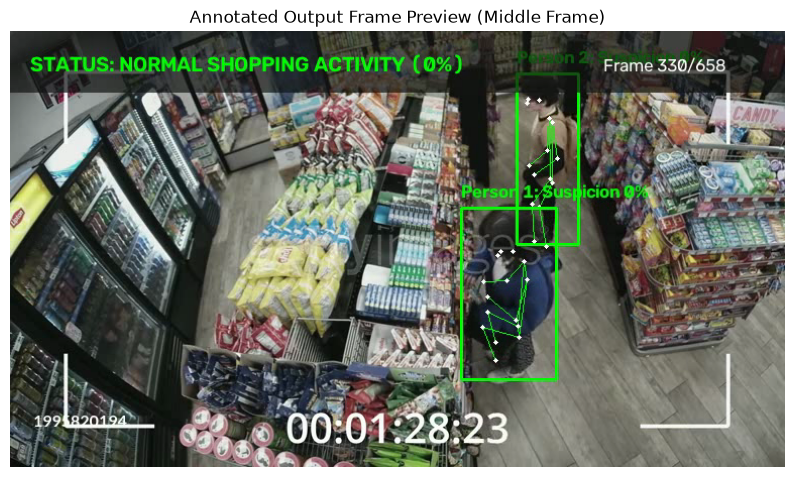

In [6]:
if os.path.exists(output_path):
    out_cap = cv2.VideoCapture(output_path)
    out_frames_count = int(out_cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Read middle frame from annotated output video for visual inspection
    out_cap.set(cv2.CAP_PROP_POS_FRAMES, int(out_frames_count / 2))
    ret, mid_frame = out_cap.read()
    out_cap.release()
    
    if ret:
        mid_frame_rgb = cv2.cvtColor(mid_frame, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(mid_frame_rgb)
        plt.title("Annotated Output Frame Preview (Middle Frame)")
        plt.axis("off")
        plt.show()
    else:
        print("Output video file created, but frame extraction failed.")
else:
    print("Output video file missing!")